<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2284 entries, 0 to 2283
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    2284 non-null   datetime64[ns]
 1   co2     2284 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 35.8 KB
None
time    0
co2     0
dtype: int64
r2_score :  [0.9909719988426708, 0.9828922680922997, 0.9737928417781063]
mean_absolute_error :  [0.3613152886852903, 0.5073380621600835, 0.645728370415216]
root_mean_squared_error :  [0.46583773064466705, 0.6455410606691538, 0.8047409058767153]


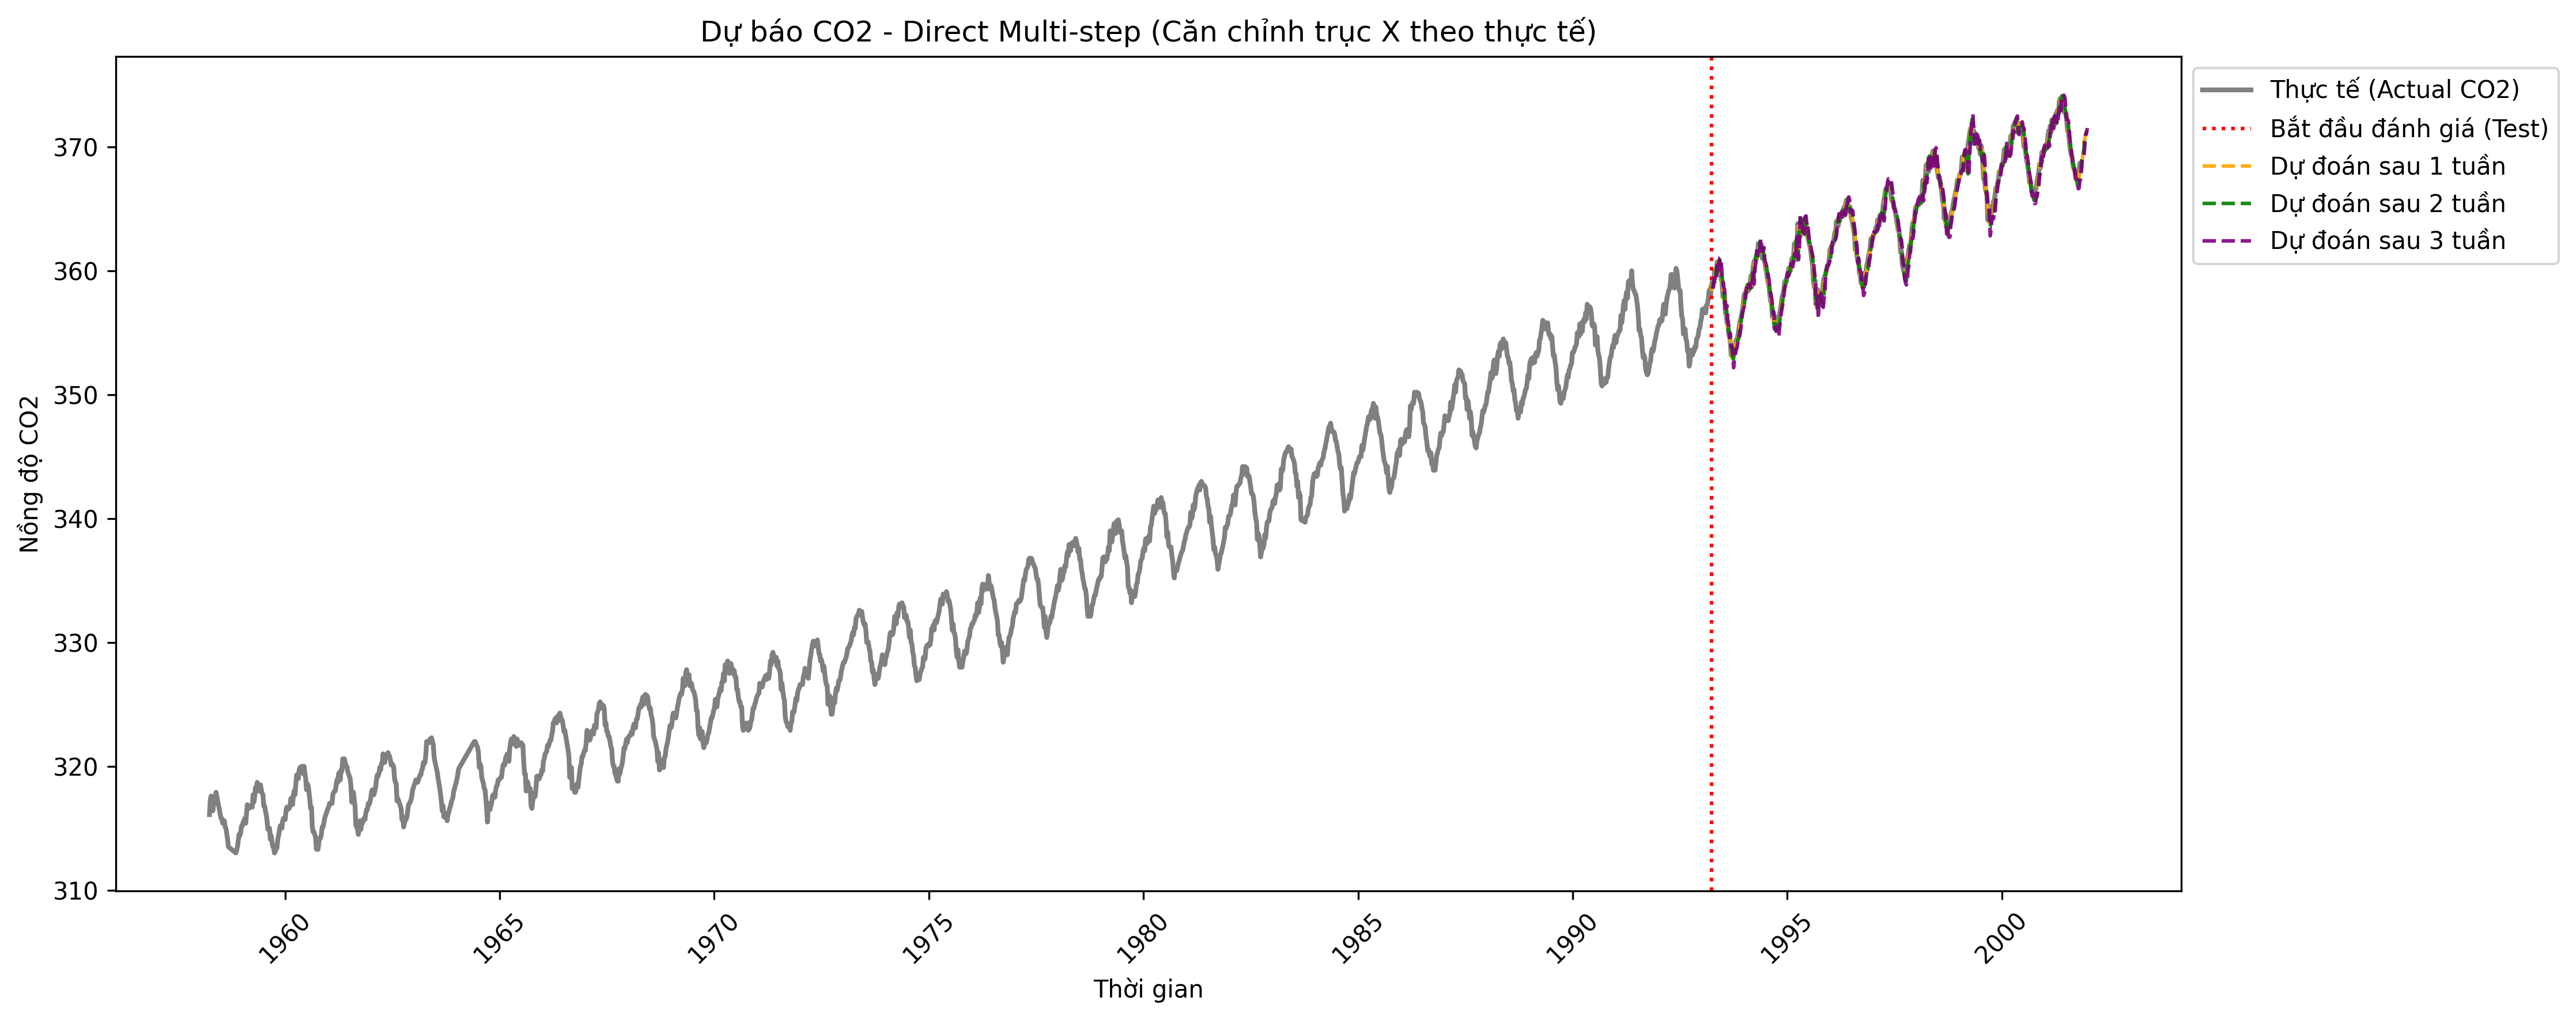

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

def create_direct_data(data,window_size=5,target_size=3):
    for i in range(1,window_size):
        data["co2_{}".format(i)]=data["co2"].shift(-i)
    for i in range(target_size):
       data['target_{}'.format(i)]=data['co2'].shift(-window_size-i)
    data=data.dropna(axis=0)
    return data
path="../data/co2.csv"
data=pd.read_csv(path)
data["time"]=pd.to_datetime(data["time"])
# xử lý các cột trống bằng nội suy
data['co2']=data['co2'].interpolate()
print(data.info())
print(data.isna().sum())
#tạo data phù hợp cho dạng direct
target_size=3
data=create_direct_data(data,6,target_size)
#chia dữ liệu
x=data.drop(['time']+['target_{}'.format(i) for i in range(target_size)],axis=1)
y=data[['target_{}'.format(i) for i in range(target_size)]]
train_size=0.8
idx=int(len(x)*train_size)
x_train,x_test=x[:idx],x[idx:]
y_train,y_test=y[:idx],y[idx:]
#train
regs=[LinearRegression() for _ in range(target_size)]
for i in range(target_size) :
    regs[i].fit(x_train,y_train['target_{}'.format(i)])
#test
y_predicts=[reg.predict(x_test) for reg in regs]
r2=[r2_score(y_predicts[i],y_test['target_{}'.format(i)]) for i in range(target_size)]
mae=[mean_absolute_error(y_predicts[i],y_test['target_{}'.format(i)]) for i in range(target_size)]
rmse=[root_mean_squared_error(y_predicts[i],y_test['target_{}'.format(i)]) for i in range(target_size)]
print("r2_score : ",r2)
print("mean_absolute_error : ",mae)
print("root_mean_squared_error : ",rmse)



fig, ax = plt.subplots(figsize=(15, 6), dpi=300)

# 1. Vẽ đường thực tế (Ground Truth)
# Dùng trực tiếp cột 'co2' hiện tại ghép với cột 'time' để tạo thành một đường chuẩn liền mạch.
ax.plot(data['time'], data['co2'], label='Thực tế (Actual CO2)', color='gray', linewidth=2)

# Đánh dấu thời điểm bắt đầu của tập Test để dễ quan sát
# Thời gian bắt đầu = thời gian của hàng idx + khoảng window_size tuần.
window_size = 6
test_start_time = data['time'].iloc[idx] + pd.to_timedelta(window_size, unit='W')
ax.axvline(x=test_start_time, color='red', linestyle=':', label='Bắt đầu đánh giá (Test)')

# 2. Vẽ 3 đường dự đoán đã được căn chỉnh trục thời gian
# Lưu ý: Khoảng cách giữa các hàng là 1 tuần (unit='W')
colors = ['orange', 'green', 'purple']

for i, y_predict in enumerate(y_predicts):
    # CĂN CHỈNH THỜI GIAN:
    # Mục tiêu dự đoán thứ i nằm ở tương lai tương ứng (window_size + i) tuần.
    # Ta cộng thêm chính xác số tuần này vào trục X của tập test.
    predict_times = data['time'][idx:] + pd.to_timedelta(window_size + i, unit='W')
    
    ax.plot(predict_times, y_predict, 
            label=f'Dự đoán sau {i+1} tuần', 
            color=colors[i], 
            linestyle='--', # Nét đứt cho dự đoán
            linewidth=1.5, 
            alpha=0.9)

ax.set_xlabel('Thời gian')
ax.set_ylabel('Nồng độ CO2')
ax.set_title('Dự báo CO2 - Direct Multi-step (Căn chỉnh trục X theo thực tế)')

# Di chuyển Legend ra ngoài
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Xoay nhãn trục X 45 độ để chữ thời gian không bị dính vào nhau
plt.xticks(rotation=45)

# ZOOM VÀO VÙNG TEST (Tùy chọn)
# Vì tập Train quá dài sẽ làm các đường test bị dồn lại nhỏ xíu. 
# Dòng code dưới đây cắt bỏ bớt phần Train hiển thị, chỉ zoom vào đoạn gần Test để dễ nhìn 3 đường.
# Nếu muốn xem toàn cảnh thì bạn có thể xóa/comment dòng này đi.
ax.set_xlim(left=data['time'].iloc[idx] - pd.to_timedelta(20, unit='W'))

# Tự động căn chỉnh lề
plt.tight_layout()
plt.show()
